In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc, images_dir
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, put_fig_letter

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# DSL


In [2]:
cycle=500
#bbox= [3.5, 5.2, 39.5, 40.5]
bbox = [0.7, 6.1, 36.6, 43.4]
from swot import browse_swot_250m
dfs = browse_swot_250m().reset_index()

#dfs_ = dfs.where((dfs.pass_number==3)&(dfs.cycle_number==500)).dropna()
#dss = xr.open_dataset(dfs.where((dfs.pass_number==3)&(dfs.cycle_number==500)).dropna().file.values[0])

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
dss = xr.open_dataset(dfs.where((dfs.pass_number==3)&(dfs.cycle_number==500)).dropna().file.values[0])

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [4]:
dss

<xarray.Dataset> Size: 467MB
Dimensions:                                  (num_lines: 4161, num_pixels: 519)
Coordinates:
    latitude                                 (num_lines, num_pixels) float64 17MB ...
    longitude                                (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/38)
    ancillary_surface_classification_flag    (num_lines, num_pixels) float32 9MB ...
    cross_track_distance                     (num_lines, num_pixels) float32 9MB ...
    cvl_cross_track_distance                 (num_lines, num_pixels) float32 9MB ...
    cvl_dac                                  (num_lines, num_pixels) float64 17MB ...
    cvl_distance_to_coast                    (num_lines, num_pixels) float64 17MB ...
    cvl_flag_val                             (num_lines, num_pixels) float32 9MB ...
    ...                                       ...
    pass_number                              (num_lines) uint16 8kB ...
    sig0_karin_2                             (num_lines, num_pixels) float32 9MB ...
    ssh_karin_2_qual                         (num_lines, num_pixels) float64 17MB ...
    time                                     (num_lines) datetime64[ns] 33kB ...
    time_tai                                 (num_lines) datetime64[ns] 33kB ...
    version                                  (num_lines) |S7 29kB ...
Attributes:
    latc:     39.39991
    lonc:     4.205744
    phi:      76.96918844368692

In [4]:
def get_dataset_eta(cycle):
    DS3 = dict()
    DS16 = dict()
    DSL4 = dict()
    
    #250 m 
    file = os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', f'3_{int(cycle)}.nc')
    if os.path.isfile(file): dss3 = xr.open_dataset(file)
    else :
        dss3 = xr.open_dataset(glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', f'3_{500}.nc'))[0])
        dss3 = dss3.where(dss3.etaf==1e3)
        
    file = os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', f'16_{int(cycle)}.nc')
    if os.path.isfile(file): dss16 = xr.open_dataset(file)
    else :
        dss16 = xr.open_dataset(glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', f'16_{500}.nc'))[0])
        dss16 = dss16.where(dss16.etaf==1e3)
        
    DS3['L3-250m'] = dss3
    DS16['L3-250m'] = dss16
    
    #2km
    file = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km','diff_only', f'pass3*.nc'))[0]
    dss3 = xr.open_dataset(file)
    if cycle in dss3.cycle_number : dss3 = dss3.sel(cycle_number=int(cycle))
    else :
        dss3 = dss3.where(dss3.etaf==1e3).sel(cycle_number=int(500))
        
    file = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km','diff_only', f'pass16*.nc'))[0]
    dss16 = xr.open_dataset(file)
    if cycle in dss16.cycle_number : dss16 = dss16.sel(cycle_number=int(cycle))
    else :
        dss16 = dss16.where(dss16.etaf==1e3).sel(cycle_number=int(500))
    
    DS3['L3-2km'] = dss3
    DS16['L3-2km'] = dss16
    
    #L4
    L4 = glob(os.path.join(zarr_dir, 'before_coloc','L4_sealevel','*'))
    DSL4['L4-global'] = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','L4_sealevel','L4_noswot_global.nc')).interp(time = dfs[dfs.cycle_number==cycle].time.mean())
    DSL4['L4-regional'] = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','L4_sealevel','L4_noswot_regional.nc')).interp(time = dfs[dfs.cycle_number==cycle].time.mean())
    DSL4['L4-SWOT-nadir'] = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','L4_sealevel','L4_withnadirswot.nc')).interp(time = dfs[dfs.cycle_number==cycle].time.mean())
    return DS3, DS16, DSL4

DS3, DS16, DSL4 = get_dataset_eta(cycle)

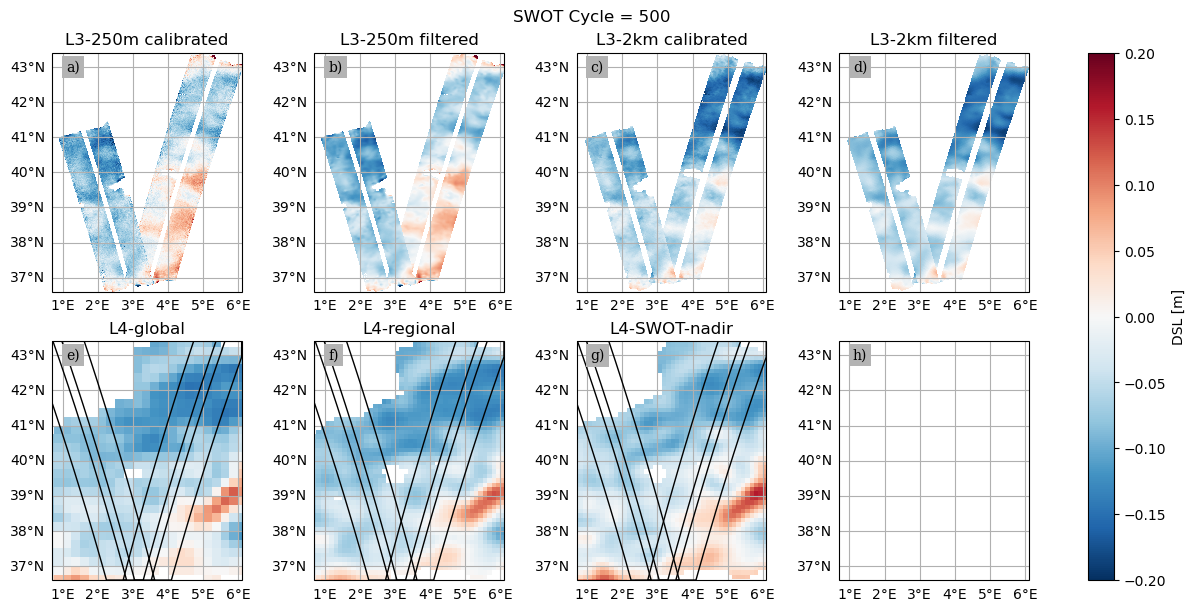

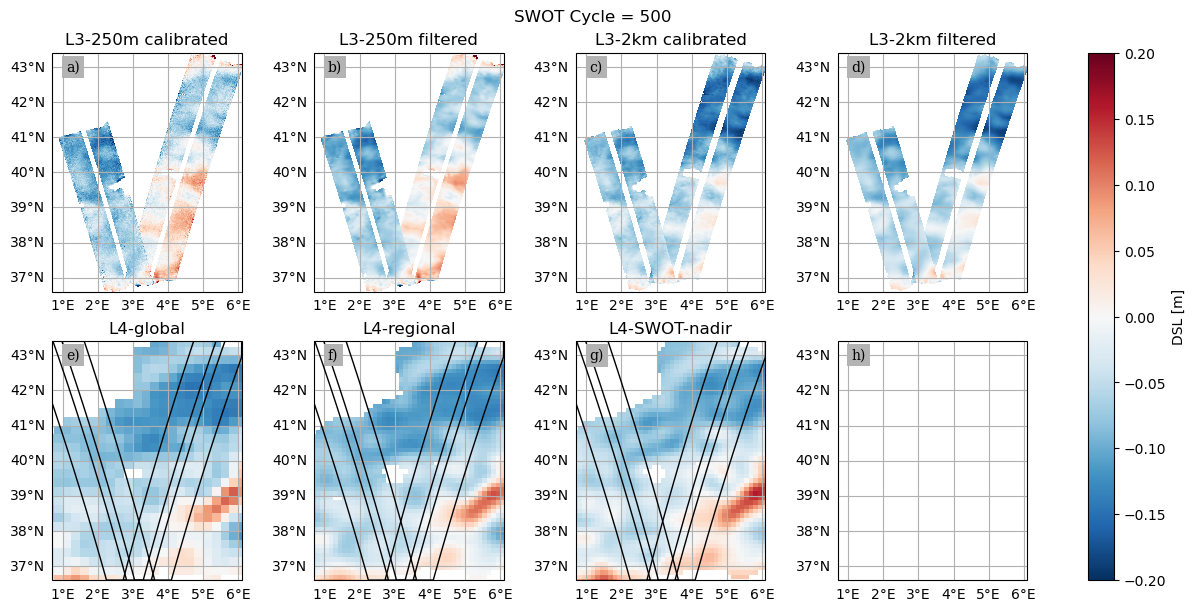

In [5]:
def plot_diff_product(DS3, DS16, DSL4):
    v = 'etaf'
    v0 = 'etac'
    
    kwargs = dict(vmin = -0.2, vmax=0.2, cmap ='RdBu_r', add_colorbar=False)
    
    fig, axs = plt.subplots(2,4 , figsize = (12,6), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    axs = axs.flatten()
    fig.patch.set_facecolor('white')#no transparancy in png
    
    i=0
    for key in DS3 :
        
        ax = axs[i+1]
        a=DS3[key][v].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        DS16[key][v].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        ax.set_title(key + ' filtered')
        
        ax = axs[i]
        DS3[key][v0].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        DS16[key][v0].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        ax.set_title(key + ' calibrated')
        
        i+=2
    
    for key in DSL4 : 
        ax = axs[i]
        DSL4[key].adt.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs, zorder=1)
        from swot import plot_swot_tracks
        plot_swot_tracks(ax, bbox)
        ax.set_title(key)
        i+=1
    
    for ax in axs : 
        gl = ax.gridlines(draw_labels=True,)
        ax.set_extent(bbox)
        #ax.coastlines("50m")
        gl.top_labels = False
        gl.right_labels = False
    fig.suptitle(f'SWOT Cycle = {int(cycle)}')
    
    fig.colorbar(a, ax=axs.ravel().tolist(), location ='right', shrink = 1, label = 'DSL [m]')

    i=0
    for l  in ['a', 'b', 'c', 'd', 'e','f', 'g', 'h']:
        put_fig_letter(fig, axs[i], l)
        i+=1
    
    return fig
plot_diff_product(DS3, DS16, DSL4)    

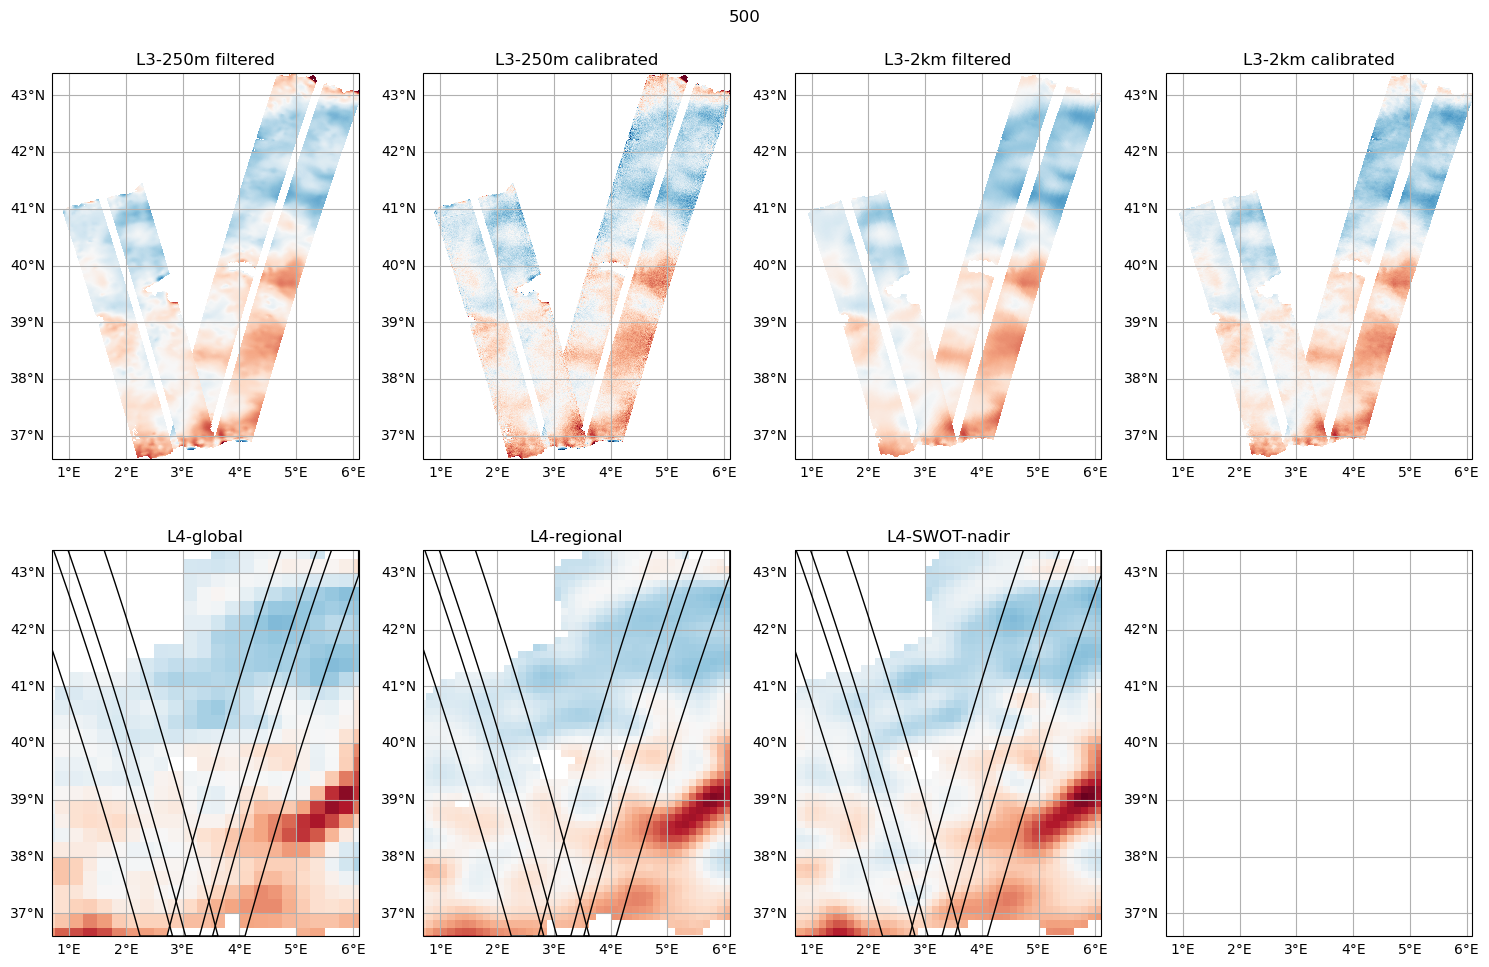

In [6]:
def plot_diff_product_eta_mean(DS3, DS16, DSL4):
    DS3m = {key : DS3[key] - DS3[key].median() for key in DS3}
    DS16m = {key : DS16[key] - DS16[key].median() for key in DS16}
    DSL4m = {key : DSL4[key] - DSL4[key].median() for key in DSL4}
    v = 'etaf'
    v0 = 'etac'
    
    kwargs = dict(vmin = -0.2, vmax=0.2, cmap ='RdBu_r', add_colorbar=False)
    
    fig, axs = plt.subplots(2,4 , figsize = (15,10), subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()
    fig.patch.set_facecolor('white')#no transparancy in png
    
    i=0
    for key in DS3m :
        ax = axs[i]
        DS3m[key][v].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        DS16m[key][v].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        ax.set_title(key + ' filtered')
        
        ax = axs[i+1]
        DS3m[key][v0].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        DS16m[key][v0].plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs)
        ax.set_title(key + ' calibrated')
        i+=2
    
    for key in DSL4m : 
        ax = axs[i]
        DSL4m[key].adt.plot(x='longitude', y='latitude',ax=ax, transform=crs,**kwargs, zorder=1)
        from swot import plot_swot_tracks
        plot_swot_tracks(ax, bbox)
        ax.set_title(key)
        i+=1
    
    for ax in axs : 
        gl = ax.gridlines(draw_labels=True,)
        ax.set_extent(bbox)
        #ax.coastlines("50m")
        gl.top_labels = False
        gl.right_labels = False
    fig.suptitle(f'{int(cycle)}')
    fig.tight_layout()
    return fig
fig = plot_diff_product_eta_mean(DS3, DS16, DSL4)

________
# Generate all images

In [27]:
cycle_n = list(dfs.cycle_number.unique())

In [31]:
cycle_n

[478,
 479,
 480,
 481,
 482,
 483,
 484,
 485,
 486,
 487,
 488,
 489,
 490,
 491,
 492,
 493,
 494,
 495,
 496,
 497,
 499,
 500,
 501,
 502,
 503,
 504,
 505,
 506,
 507,
 508,
 509,
 510,
 511,
 512,
 513,
 514,
 515,
 516,
 517,
 518,
 519,
 520,
 521,
 522,
 523,
 524,
 525,
 529,
 530,
 531,
 532,
 533,
 534,
 535,
 536,
 537,
 538,
 539,
 540,
 541,
 542,
 543,
 544,
 545,
 546,
 547,
 548,
 549,
 550,
 551,
 552,
 553,
 554,
 555,
 556,
 557,
 558,
 559,
 560,
 561,
 562,
 563,
 564,
 565,
 567,
 569,
 570,
 571,
 573,
 574,
 575,
 576,
 577,
 578,
 498,
 566,
 572]

In [28]:
for cycle in cycle_n :
    DS3, DS16, DSL4 = get_dataset_eta(cycle)
    fig = plot_diff_product_eta_mean(DS3, DS16, DSL4)
    fig.savefig(os.path.join(images_dir,'diff_product_eta', f'{int(cycle)}.png'))
    print(cycle)
    plt.close()

478
479
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497


/dev/shm/pbs.2904903.datarmor0/ipykernel_8520/3994968554.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2,4 , figsize = (15,10), subplot_kw={'projection': ccrs.PlateCarree()})


499
500
501
502
503
504
505
506
507
508
509
510
511
512
513
514
515
516
517
518
519
520
521
522
523
524
525
529
530
531
532
533
534
535
536
537
538
539
540
541
542
543
544
545
546
547
548
549
550
551
552
553
554
555
556
557
558
559
560
561
562
563
564
565
567
569
570
571
573
574
575
576
577
578
498
566
572
Error in callback <function _draw_all_if_interactive at 0x2aaae3424790> (for post_execute):


Exception ignored in: <function CachingFileManager.__del__ at 0x2aaae2146670>
Traceback (most recent call last):
  File "/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/file_manager.py", line 236, in __del__
    def __del__(self) -> None:
KeyboardInterrupt: 


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x2aaafa767040> (for post_execute):



KeyboardInterrupt



In [32]:
# make gif
from PIL import Image


def make_gif(frame_folder, duration=200):
    frames = [Image.open(image) for image in sorted(glob(f"{frame_folder}/*.png"))]
    frame_one = frames[0]
    frame_one.save(
        f"{frame_folder}.gif",
        format="GIF",
        append_images=frames,
        save_all=True,
        duration=duration,
        loop=0,
    )

In [33]:
make_gif(os.path.join(images_dir,'diff_product_eta'))